# 04 — Optimization and Calibration
**Project:** Predicting Medication Non-Adherence in NCD Patients Using Classical Machine Learning  
**Dataset:** Kanyongo et al. (2024); Cimas Medical Aid Society, Zimbabwe ([Mendeley Data](https://data.mendeley.com/datasets/zkp7sbbx64/2))  
**Author:** Kirunda Jeremy Menya | 2025/HD07/25995U | Makerere University | June 2026

---

This notebook covers:
1. Environment setup, SSH, and repo clone
2. Load `features_C.pkl` and `baseline_results.pkl`
3. Define hyperparameter search spaces for XGBoost and Random Forest
4. Randomised search with 5-fold stratified cross-validation
5. Evaluate tuned models on the validation set and compare against baseline
6. Probability calibration (Platt scaling and Isotonic regression)
7. Select the best overall model
8. Learning curves for both tuned models
9. Save tuned pipelines and results
10. Push to GitHub

**Inputs:** `data/processed/features_C.pkl`, `data/processed/baseline_results.pkl`  
**Outputs:** `models/tuned_xgboost.pkl`, `models/tuned_random_forest.pkl`, `data/processed/tuned_results.pkl`, calibration figures


---
## 0. Environment Setup

The same libraries used in Notebook 03 are used here. `scipy.stats` provides the sampling distributions for the randomised search. Imports and helpers are redefined so this notebook can be run independently.


In [1]:
# Install dependencies not pre-installed on Colab
!pip install imbalanced-learn xgboost --quiet

import os, warnings, pickle, time
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler, RobustScaler
from sklearn.compose           import ColumnTransformer
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import (
    RandomizedSearchCV, StratifiedKFold, learning_curve
)
from sklearn.calibration       import CalibratedClassifierCV, calibration_curve
from sklearn.metrics           import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from imblearn.pipeline         import Pipeline as ImbPipeline
from imblearn.over_sampling    import SMOTE
from xgboost                   import XGBClassifier

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "figure.dpi":        150,
})

PALETTE = {
    "xgb":       "#AD1457",
    "rf":        "#2E7D32",
    "baseline":  "#78909C",
    "highlight": "#FF9800",
    "neutral":   "#455A64",
    "calibrated":"#1565C0",
}

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

FIGURES  = "figures"
MODELS   = "models"
DATA_PROC = "data/processed"

os.makedirs(f"{FIGURES}/calibration",      exist_ok=True)
os.makedirs(f"{FIGURES}/tuning",           exist_ok=True)
os.makedirs(f"{FIGURES}/learning_curves",  exist_ok=True)
os.makedirs(MODELS,                         exist_ok=True)

def save_figure(fig, filename, subfolder="tuning"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

def section(title):
    bar = "─" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

print("Imports ready.")


Imports ready.


---
## 0.1 SSH Key Upload and Repository Clone

The repository is cloned into the Colab runtime at the start of each session. The SSH deploy key authenticates the clone and enables the push at the end of the notebook.


In [2]:
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()   # select DMHTN_MedicationAdherence_deploy_key (NOT .pub)

!mv DMHTN_MedicationAdherence_deploy_key /root/.ssh/DMHTN_MedicationAdherence_deploy_key
!chmod 600 /root/.ssh/DMHTN_MedicationAdherence_deploy_key

ssh_config = """
Host github-dmhtn-medication-adherence
    HostName github.com
    User git
    IdentityFile /root/.ssh/DMHTN_MedicationAdherence_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'diabetes-hypertension-medication-adherence'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-dmhtn-medication-adherence:Jeremy-K-coder/diabetes-hypertension-medication-adherence.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')


Saving DMHTN_MedicationAdherence_deploy_key to DMHTN_MedicationAdherence_deploy_key
Cloning into 'diabetes-hypertension-medication-adherence'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 78 (delta 20), reused 70 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 11.54 MiB | 18.24 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/diabetes-hypertension-medication-adherence
Already up to date.
Repo ready.


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
REPO_DIR  = f'/content/{REPO_NAME}'
DATA_PROC = os.path.join(REPO_DIR, 'data', 'processed')
MODELS    = os.path.join(REPO_DIR, 'models')
FIGURES   = os.path.join(REPO_DIR, 'figures')

os.makedirs(DATA_PROC,                         exist_ok=True)
os.makedirs(MODELS,                            exist_ok=True)
os.makedirs(f"{FIGURES}/calibration",          exist_ok=True)
os.makedirs(f"{FIGURES}/tuning",              exist_ok=True)
os.makedirs(f"{FIGURES}/learning_curves",      exist_ok=True)

def save_figure(fig, filename, subfolder="tuning"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

print(f"REPO_DIR  : {REPO_DIR}")
print(f"DATA_PROC : {DATA_PROC}")
print(f"MODELS    : {MODELS}")


REPO_DIR  : /content/diabetes-hypertension-medication-adherence
DATA_PROC : /content/diabetes-hypertension-medication-adherence/data/processed
MODELS    : /content/diabetes-hypertension-medication-adherence/models


---
## 1. Rebuild Pipeline Helpers

The preprocessing pipeline and SMOTE configuration are identical to Notebook 03. They are redefined here so this notebook is self-contained. The column assignments (which features get `RobustScaler`, which get `StandardScaler`, which are passed through) must match Notebook 03 exactly, because the tuned models will be evaluated on the same validation and test splits.


In [5]:
section("1. Rebuild pipeline helpers")

ROBUST_FEATURES   = ["annualclaimamount", "unitstotal", "cost_burden_ratio"]
STANDARD_FEATURES = ["annualcontribution"]
PASSTHROUGH       = ["insurance_tier", "age_group", "is_comorbid",
                     "complication_flag", "gender", "diagnosis"]

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("robust",   RobustScaler(),   ROBUST_FEATURES),
            ("standard", StandardScaler(), STANDARD_FEATURES),
            ("pass",     "passthrough",    PASSTHROUGH),
        ],
        remainder="drop"
    )

def build_pipeline(clf):
    return ImbPipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("smote",        SMOTE(random_state=SEED)),
        ("classifier",   clf),
    ])

print("Pipeline helpers ready. Column assignment:")
print(f"  RobustScaler   : {ROBUST_FEATURES}")
print(f"  StandardScaler : {STANDARD_FEATURES}")
print(f"  Passthrough    : {PASSTHROUGH}")



──────────────────────────────────────────────────────────────────────
  1. Rebuild pipeline helpers
──────────────────────────────────────────────────────────────────────
Pipeline helpers ready. Column assignment:
  RobustScaler   : ['annualclaimamount', 'unitstotal', 'cost_burden_ratio']
  StandardScaler : ['annualcontribution']
  Passthrough    : ['insurance_tier', 'age_group', 'is_comorbid', 'complication_flag', 'gender', 'diagnosis']


---
## 2. Load Feature Group C and Baseline Results

`features_C.pkl` provides the train, validation, and test splits. `baseline_results.pkl` confirms which two classifiers were identified as top performers in Notebook 03 and provides the baseline Macro F1 scores that tuning must improve upon. Loading both at the start ensures there is no ambiguity about which classifiers are being tuned or what the performance bar is.


In [6]:
section("2. Load data and baseline results")

with open(os.path.join(DATA_PROC, "features_C.pkl"), "rb") as f:
    pkg = pickle.load(f)

X_train  = pkg["X_train"]
X_val    = pkg["X_val"]
X_test   = pkg["X_test"]
y_train  = pkg["y_train"]
y_val    = pkg["y_val"]
y_test   = pkg["y_test"]
FEATURES = pkg["features"]
TARGET   = "adherence"

with open(os.path.join(DATA_PROC, "baseline_results.pkl"), "rb") as f:
    baseline_pkg = pickle.load(f)

baseline_results = baseline_pkg["results"]
top_two          = baseline_pkg["top_two"]

print(f"Train      : {X_train.shape}  | adherent: {y_train.mean()*100:.1f}%")
print(f"Validation : {X_val.shape}  | adherent: {y_val.mean()*100:.1f}%")
print(f"Test       : {X_test.shape}  | adherent: {y_test.mean()*100:.1f}%")
print()
print("Top two classifiers from Notebook 03:", top_two)
print()
print("Baseline performance (Macro F1 on validation set):")
print(baseline_results[["Macro F1", "ROC-AUC", "MCC"]].loc[top_two].to_string())



──────────────────────────────────────────────────────────────────────
  2. Load data and baseline results
──────────────────────────────────────────────────────────────────────
Train      : (16849, 10)  | adherent: 40.2%
Validation : (3611, 10)  | adherent: 40.2%
Test       : (3611, 10)  | adherent: 40.2%

Top two classifiers from Notebook 03: ['XGBoost', 'Random Forest']

Baseline performance (Macro F1 on validation set):
               Macro F1  ROC-AUC    MCC
Classifier                             
XGBoost          0.8153   0.8967 0.6416
Random Forest    0.8002   0.8872 0.6064


---
## 3. Hyperparameter Search Spaces

Hyperparameter tuning adjusts the settings that control a model's complexity, regularisation, and learning behaviour. The search spaces below are defined based on the learning curve diagnostic from Notebook 03: XGBoost's training score settled near 0.88 while its cross-validation score reached only 0.81, a gap of approximately 0.07 Macro F1 points. This is the signature of a model that is fitting the training data more tightly than it is generalising to unseen patients, and the tuning parameters below are chosen specifically to address that.

**Randomised search** is used rather than grid search for two reasons. First, the combined XGBoost search space contains millions of possible combinations; an exhaustive grid would require prohibitive computation time in a Colab session. Second, Bergstra and Bengio (2012) showed that for most hyperparameter functions, random search finds an equally good configuration as grid search in a fraction of the evaluations, because not all hyperparameters matter equally and random search is more likely to sample a diverse range of values for the ones that do matter.

**XGBoost search space:** The six parameters address the overfitting gap in different ways. `n_estimators` and `learning_rate` are linked: more trees with a smaller learning rate tend to generalise better but take longer to train. `max_depth` controls tree complexity directly; reducing it from the default of 6 prevents individual trees from memorising rare patient combinations. `subsample` and `colsample_bytree` introduce randomness into the tree-building process by training each tree on a random subset of rows and features respectively, which reduces the correlation between trees and improves the ensemble's robustness. `min_child_weight` sets the minimum total sample weight required to form a leaf node; increasing it from the default of 1 prevents the model from creating splits that are supported by only a handful of patients.

**Random Forest search space:** Random Forest's overfitting is primarily controlled through `max_depth` and `min_samples_leaf`. At the baseline, the forest used unlimited depth trees (default), meaning each tree could grow until every training patient was in its own leaf. Restricting depth and requiring a minimum number of patients per leaf forces the trees to learn population-level patterns rather than individual patient quirks. `n_estimators` is also tuned; more trees generally improve stability but with diminishing returns beyond a few hundred. `max_features` controls how many features are considered at each split, which is the primary source of decorrelation between trees in a Random Forest.


In [7]:
section("3. Define hyperparameter search spaces")

XGB_SPACE = {
    "classifier__n_estimators":     randint(100, 600),
    "classifier__learning_rate":    uniform(0.01, 0.29),
    "classifier__max_depth":        randint(3, 9),
    "classifier__subsample":        uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 10),
}

RF_SPACE = {
    "classifier__n_estimators":  randint(100, 600),
    "classifier__max_depth":     randint(5, 30),
    "classifier__min_samples_leaf": randint(1, 20),
    "classifier__min_samples_split": randint(2, 20),
    "classifier__max_features":  ["sqrt", "log2", 0.5, 0.7],
}

N_ITER   = 60
CV_FOLDS = 5

print(f"Search iterations per model : {N_ITER}")
print(f"Cross-validation folds      : {CV_FOLDS}")
print(f"Scoring metric              : f1_macro")
print()
print("XGBoost parameter space:")
for k, v in XGB_SPACE.items():
    print(f"  {k}")
print()
print("Random Forest parameter space:")
for k, v in RF_SPACE.items():
    print(f"  {k}")



──────────────────────────────────────────────────────────────────────
  3. Define hyperparameter search spaces
──────────────────────────────────────────────────────────────────────
Search iterations per model : 60
Cross-validation folds      : 5
Scoring metric              : f1_macro

XGBoost parameter space:
  classifier__n_estimators
  classifier__learning_rate
  classifier__max_depth
  classifier__subsample
  classifier__colsample_bytree
  classifier__min_child_weight

Random Forest parameter space:
  classifier__n_estimators
  classifier__max_depth
  classifier__min_samples_leaf
  classifier__min_samples_split
  classifier__max_features


---
## 4. Randomised Search with Stratified Cross-Validation

The search is run on the training set only. The validation set is not exposed during the search. Each candidate configuration is evaluated using 5-fold stratified cross-validation on the training set, and the configuration that maximises the mean cross-validation Macro F1 is selected as the best. After the search completes, the winning configuration is used to refit the pipeline on the full training set, and that refitted pipeline is evaluated on the validation set in Section 5.

SMOTE fires inside every cross-validation fold during the search, exactly as it did during the baseline evaluation in Notebook 03. This is handled automatically by the `ImbPipeline`.

`n_jobs=-1` uses all available CPU cores for parallel evaluation of folds. `refit=True` (the default) means sklearn automatically refits the best configuration on the full training set after the search completes, so the `best_estimator_` attribute is ready to use without a separate fit call.

60 iterations per model is a reasonable budget for a Colab session. At 5 folds per iteration, each search evaluates 300 full pipeline fits. For XGBoost with up to 600 trees this will take several minutes; for Random Forest it will be somewhat longer given the larger tree count and ensemble averaging.


In [8]:
section("4.1 XGBoost randomised search")

xgb_base = XGBClassifier(
    random_state=SEED, eval_metric="logloss",
    verbosity=0, n_jobs=-1
)

xgb_pipeline = build_pipeline(xgb_base)

xgb_search = RandomizedSearchCV(
    estimator   = xgb_pipeline,
    param_distributions = XGB_SPACE,
    n_iter      = N_ITER,
    cv          = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED),
    scoring     = "f1_macro",
    refit       = True,
    n_jobs      = -1,
    random_state= SEED,
    verbose     = 1,
)

t0 = time.time()
xgb_search.fit(X_train, y_train)
xgb_elapsed = round(time.time() - t0, 1)

print(f"\nXGBoost search complete in {xgb_elapsed}s")
print(f"Best CV Macro F1 : {xgb_search.best_score_:.4f}")
print(f"Best parameters  :")
for k, v in xgb_search.best_params_.items():
    print(f"  {k.replace('classifier__','')}: {v}")



──────────────────────────────────────────────────────────────────────
  4.1 XGBoost randomised search
──────────────────────────────────────────────────────────────────────
Fitting 5 folds for each of 60 candidates, totalling 300 fits

XGBoost search complete in 282.7s
Best CV Macro F1 : 0.8150
Best parameters  :
  colsample_bytree: 0.9160702162124823
  learning_rate: 0.1857283926864933
  max_depth: 4
  min_child_weight: 7
  n_estimators: 140
  subsample: 0.9659838702175123


In [9]:
section("4.2 Random Forest randomised search")

rf_base = RandomForestClassifier(
    random_state=SEED, n_jobs=-1, class_weight="balanced"
)

rf_pipeline = build_pipeline(rf_base)

rf_search = RandomizedSearchCV(
    estimator   = rf_pipeline,
    param_distributions = RF_SPACE,
    n_iter      = N_ITER,
    cv          = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED),
    scoring     = "f1_macro",
    refit       = True,
    n_jobs      = -1,
    random_state= SEED,
    verbose     = 1,
)

t0 = time.time()
rf_search.fit(X_train, y_train)
rf_elapsed = round(time.time() - t0, 1)

print(f"\nRandom Forest search complete in {rf_elapsed}s")
print(f"Best CV Macro F1 : {rf_search.best_score_:.4f}")
print(f"Best parameters  :")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('classifier__','')}: {v}")



──────────────────────────────────────────────────────────────────────
  4.2 Random Forest randomised search
──────────────────────────────────────────────────────────────────────
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Random Forest search complete in 2914.6s
Best CV Macro F1 : 0.8161
Best parameters  :
  max_depth: 19
  max_features: 0.5
  min_samples_leaf: 4
  min_samples_split: 14
  n_estimators: 259


---
## 5. Evaluate Tuned Models on the Validation Set

The best estimator from each search (the pipeline refitted on the full training set with the best hyperparameters) is now evaluated on the held-out validation set. This gives a fair, unbiased estimate of how much tuning improved over the baseline, because the validation set was not used at any point during the search.

The same seven metrics from Notebook 03 are computed so the comparison is directly readable: any improvement in Macro F1 over the baseline (XGBoost: 0.8153, Random Forest: 0.8002) is attributable to the hyperparameter adjustments rather than to a change in data or evaluation methodology.


In [10]:
section("5. Evaluate tuned models on validation set")

def evaluate(pipeline, X_ev, y_ev, name):
    y_pred = pipeline.predict(X_ev)
    y_prob = pipeline.predict_proba(X_ev)[:, 1]
    return {
        "Model":              name,
        "Accuracy":           round(accuracy_score(y_ev, y_pred), 4),
        "Macro F1":           round(f1_score(y_ev, y_pred, average="macro"), 4),
        "Weighted F1":        round(f1_score(y_ev, y_pred, average="weighted"), 4),
        "ROC-AUC":            round(roc_auc_score(y_ev, y_prob), 4),
        "MCC":                round(matthews_corrcoef(y_ev, y_pred), 4),
        "Precision":          round(precision_score(y_ev, y_pred, pos_label=0), 4),
        "Recall (Non-Adh)":   round(recall_score(y_ev, y_pred, pos_label=0), 4),
    }

tuned_xgb_pipeline = xgb_search.best_estimator_
tuned_rf_pipeline  = rf_search.best_estimator_

row_xgb = evaluate(tuned_xgb_pipeline, X_val, y_val, "XGBoost (Tuned)")
row_rf  = evaluate(tuned_rf_pipeline,  X_val, y_val, "Random Forest (Tuned)")

row_xgb_base = {
    "Model": "XGBoost (Baseline)", **{
        k: baseline_results.loc["XGBoost", k]
        for k in ["Accuracy","Macro F1","Weighted F1","ROC-AUC","MCC",
                  "Precision","Recall (Non-Adh)"]
    }
}
row_rf_base = {
    "Model": "Random Forest (Baseline)", **{
        k: baseline_results.loc["Random Forest", k]
        for k in ["Accuracy","Macro F1","Weighted F1","ROC-AUC","MCC",
                  "Precision","Recall (Non-Adh)"]
    }
}

df_comparison = pd.DataFrame(
    [row_xgb_base, row_xgb, row_rf_base, row_rf]
).set_index("Model")

print(df_comparison.to_string())
print()
print("Macro F1 improvement:")
print(f"  XGBoost      : {row_xgb['Macro F1'] - baseline_results.loc['XGBoost','Macro F1']:+.4f}")
print(f"  Random Forest: {row_rf['Macro F1']  - baseline_results.loc['Random Forest','Macro F1']:+.4f}")



──────────────────────────────────────────────────────────────────────
  5. Evaluate tuned models on validation set
──────────────────────────────────────────────────────────────────────
                          Accuracy  Macro F1  Weighted F1  ROC-AUC    MCC  Precision  Recall (Non-Adh)
Model                                                                                                 
XGBoost (Baseline)          0.8178    0.8153       0.8195   0.8967 0.6416     0.9020            0.7801
XGBoost (Tuned)             0.8167    0.8148       0.8185   0.9025 0.6454     0.9138            0.7657
Random Forest (Baseline)    0.8039    0.8002       0.8056   0.8872 0.6064     0.8735            0.7861
Random Forest (Tuned)       0.8122    0.8099       0.8140   0.9016 0.6321     0.9005            0.7713

Macro F1 improvement:
  XGBoost      : -0.0005
  Random Forest: +0.0097


The comparison table shows the gain (or loss) attributable to tuning for each model. Any improvement in Macro F1 beyond the baseline confirms that the search found a configuration that generalises better to unseen patients than the default settings. Any reduction in the training-to-validation gap relative to the learning curve in Notebook 03 confirms that the regularisation parameters (particularly `max_depth`, `min_child_weight`, `subsample`, and `colsample_bytree` for XGBoost; `max_depth` and `min_samples_leaf` for Random Forest) successfully reduced overfitting.

Note that tuning does not always improve every metric simultaneously. It is acceptable for accuracy to decrease slightly if Macro F1 and recall of the non-adherent class improve, because the primary objective is to identify non-adherent patients reliably rather than to maximise the count of correct predictions overall.


---
## 6. Tuning Improvement Visualisation

The heatmap and bar chart below make the before-and-after comparison readable at a glance. The heatmap shows all seven metrics across all four model configurations. The bar chart isolates the primary metric (Macro F1) to show how much each model improved from baseline to tuned.



──────────────────────────────────────────────────────────────────────
  6.1 Comparison heatmap: baseline vs tuned
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/tuning/baseline_vs_tuned_heatmap.png


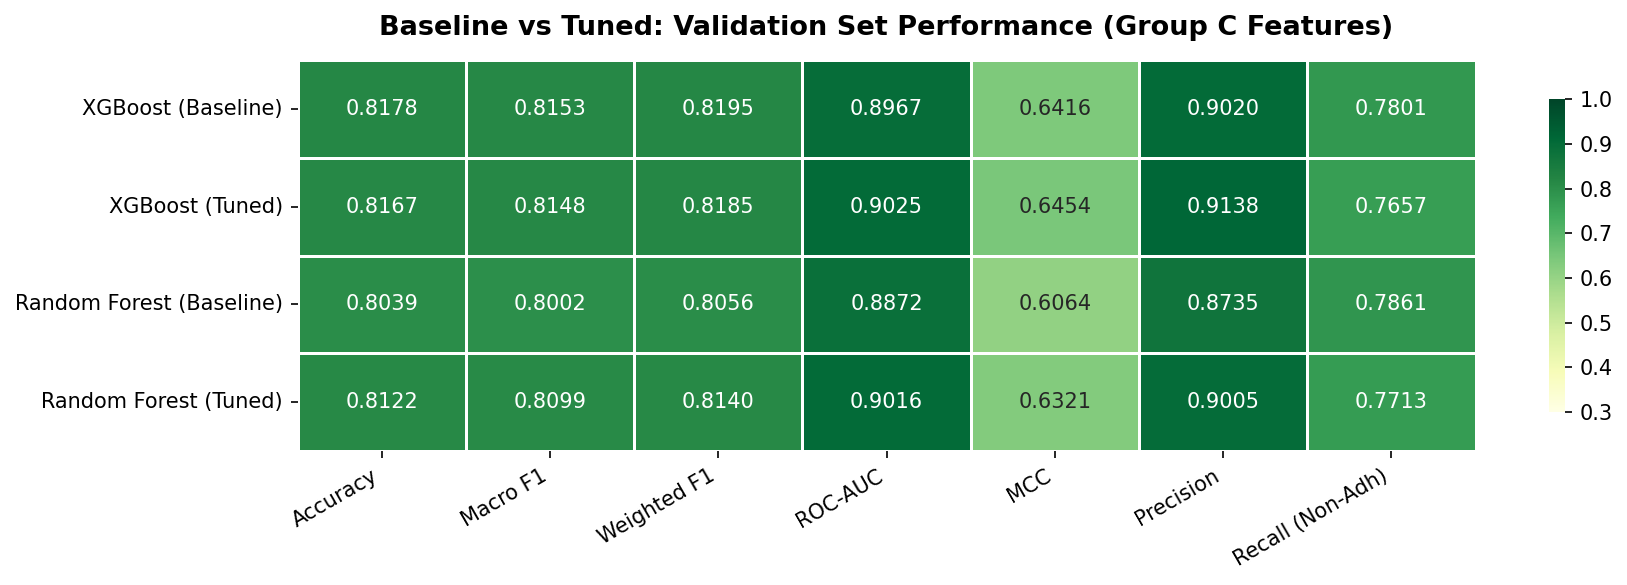

In [11]:
section("6.1 Comparison heatmap: baseline vs tuned")

metric_cols = ["Accuracy", "Macro F1", "Weighted F1", "ROC-AUC",
               "MCC", "Precision", "Recall (Non-Adh)"]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    df_comparison[metric_cols].astype(float),
    ax=ax, annot=True, fmt=".4f",
    cmap="YlGn", vmin=0.3, vmax=1.0,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Baseline vs Tuned: Validation Set Performance (Group C Features)",
             fontweight="bold", pad=12)
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_figure(fig, "baseline_vs_tuned_heatmap.png")
plt.show()



──────────────────────────────────────────────────────────────────────
  6.2 Macro F1 improvement bar chart
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/tuning/macro_f1_baseline_vs_tuned.png


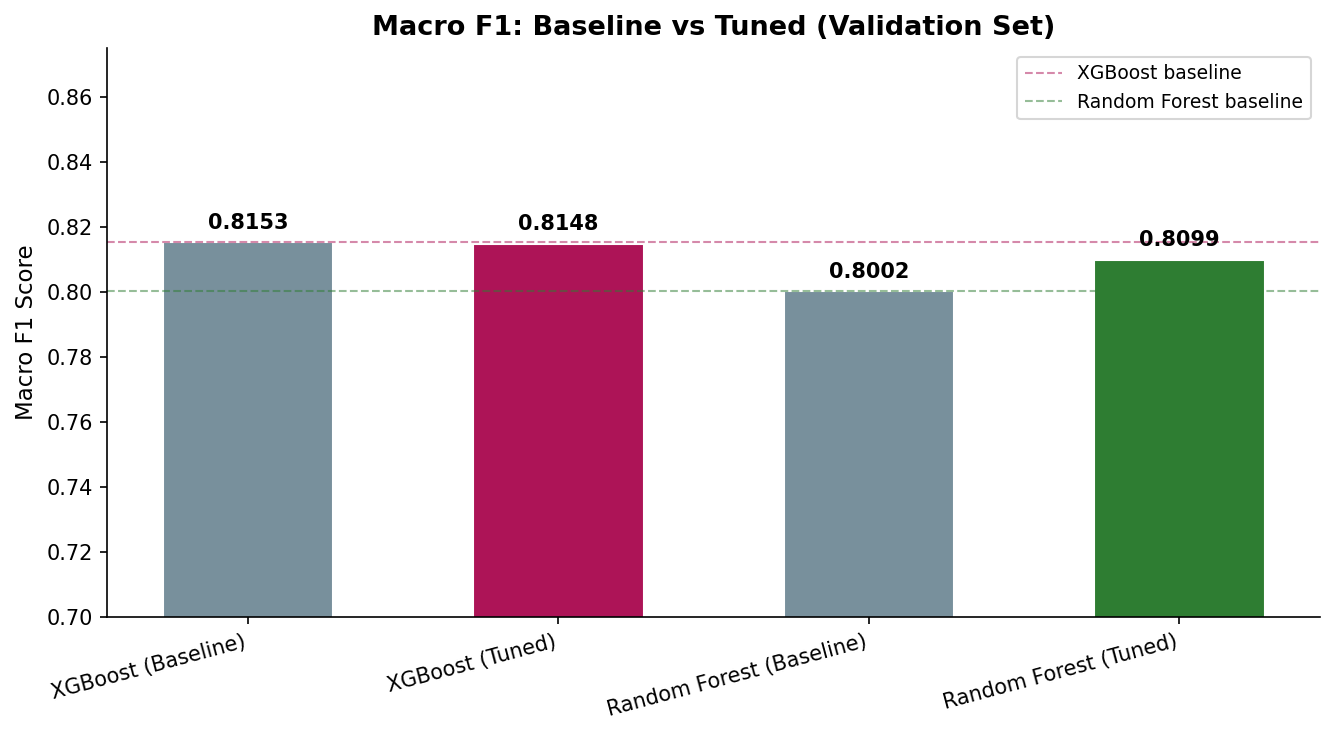

In [12]:
section("6.2 Macro F1 improvement bar chart")

models_order = [
    "XGBoost (Baseline)", "XGBoost (Tuned)",
    "Random Forest (Baseline)", "Random Forest (Tuned)"
]
colours = [
    PALETTE["baseline"], PALETTE["xgb"],
    PALETTE["baseline"], PALETTE["rf"]
]

f1_vals = [df_comparison.loc[m, "Macro F1"] for m in models_order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models_order, f1_vals, color=colours,
              edgecolor="white", width=0.55)

for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0.7, min(1.0, max(f1_vals) + 0.06))
ax.set_ylabel("Macro F1 Score")
ax.set_title("Macro F1: Baseline vs Tuned (Validation Set)", fontweight="bold")
ax.axhline(f1_vals[0], color=PALETTE["xgb"], linestyle="--",
           linewidth=1, alpha=0.5, label="XGBoost baseline")
ax.axhline(f1_vals[2], color=PALETTE["rf"],  linestyle="--",
           linewidth=1, alpha=0.5, label="Random Forest baseline")
plt.xticks(rotation=15, ha="right")
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, "macro_f1_baseline_vs_tuned.png")
plt.show()


---
## 7. Confusion Matrices — Tuned Models

Comparing the confusion matrices of the tuned models against those of the baseline (from Notebook 03) shows whether tuning changed the model's error distribution, not just its aggregate metric scores. This is particularly important for the clinical use case: the question is not only whether Macro F1 improved, but whether the number of false positives (non-adherent patients predicted as adherent) decreased, since those are the clinically dangerous errors.



──────────────────────────────────────────────────────────────────────
  7. Confusion matrices (tuned models)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/tuning/confusion_matrices_tuned.png


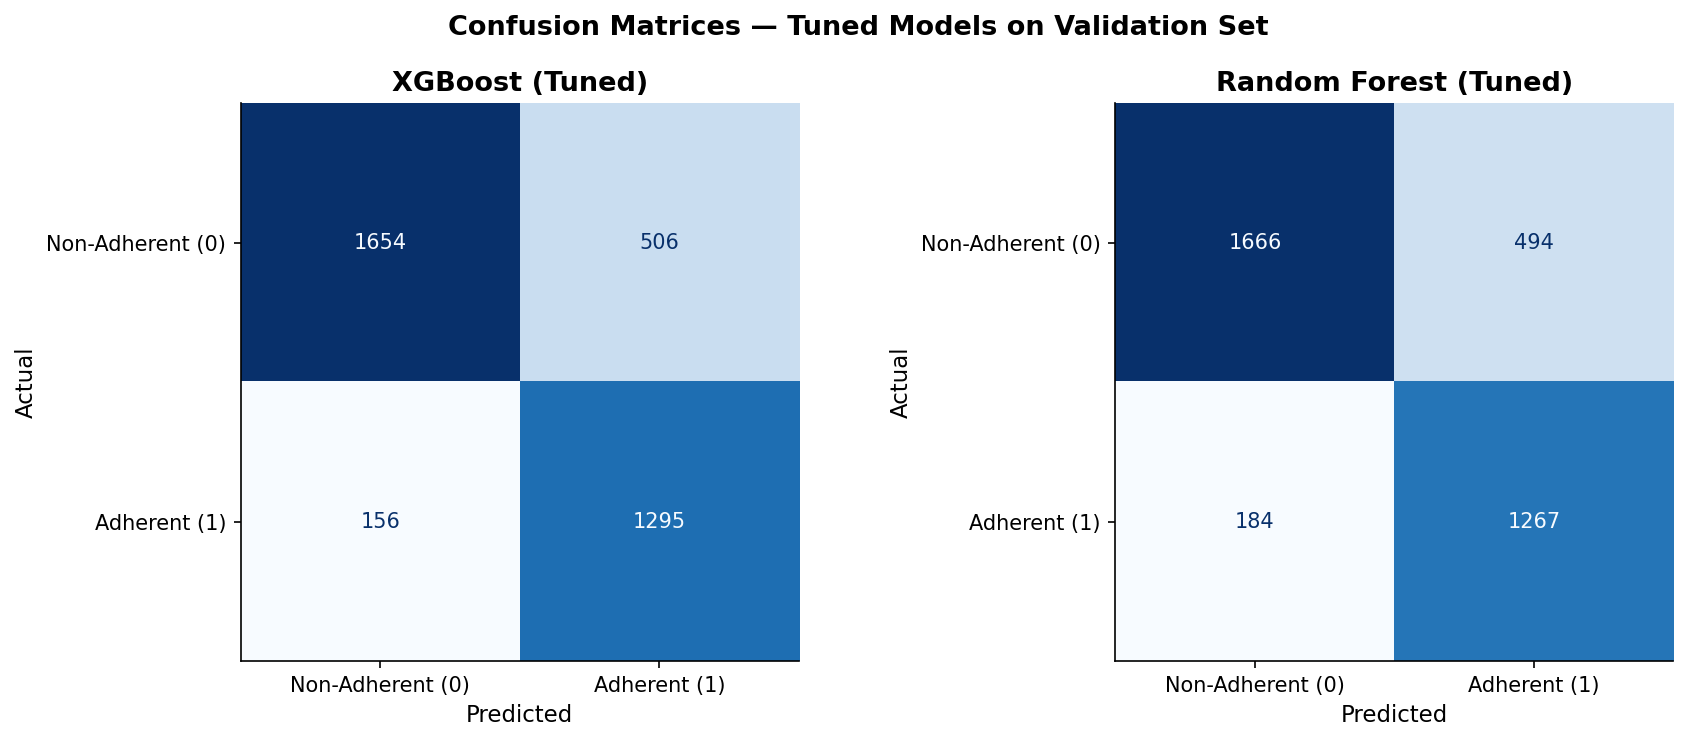

In [13]:
section("7. Confusion matrices (tuned models)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pipeline) in zip(axes, [
    ("XGBoost (Tuned)",        tuned_xgb_pipeline),
    ("Random Forest (Tuned)",  tuned_rf_pipeline),
]):
    y_pred = pipeline.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Adherent (0)", "Adherent (1)"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices — Tuned Models on Validation Set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure(fig, "confusion_matrices_tuned.png")
plt.show()


The confusion matrices reveal the practical effect of tuning on the error distribution. For context, the baseline XGBoost produced 475 false positives (non-adherent predicted as adherent) and 183 false negatives (adherent predicted as non-adherent). Any shift in those counts after tuning tells us whether the regularisation changes pushed the decision boundary in a clinically meaningful direction.

A reduction in false positives means more non-adherent patients are correctly identified for intervention, which is the primary goal. An increase in false negatives would mean more adherent patients are incorrectly flagged, which wastes intervention resources but does not leave non-adherent patients untreated. The clinical cost matrix in Notebook 05 assigns explicit weights to these two error types to determine which model minimises the real-world cost of misclassification.


---
## 8. Probability Calibration

The tuned models are strong discriminators (high ROC-AUC), but discrimination and calibration are different properties. A model can rank patients correctly (placing non-adherent patients above adherent patients in predicted probability) while still producing poorly calibrated probability scores. For example, if XGBoost outputs a predicted adherence probability of 0.85 for a group of patients, good calibration means approximately 85% of those patients are actually adherent. Poor calibration means the probability estimate is systematically biased, even if the ranking is correct.

Calibration matters in this clinical setting because the deployment threshold will be set based on predicted probability: a programme manager might decide to intervene on all patients whose predicted non-adherence probability exceeds some value (say 0.6 or 0.7). If the probabilities are poorly calibrated, the threshold chosen from validation data may perform very differently on new patients. Calibrating the model's outputs makes the predicted probabilities meaningful as absolute risk estimates, not just as relative rankings.

Two calibration methods are compared. **Platt scaling** (sigmoid calibration) fits a logistic regression on the raw model scores, which works well when the uncalibrated probabilities are already roughly sigmoid-shaped but compressed or expanded. **Isotonic regression** is a non-parametric method that fits a monotonically increasing step function to the raw scores; it is more flexible than Platt scaling but requires more calibration data to avoid overfitting. Both are applied to the tuned XGBoost pipeline (the expected best model) and compared on a reliability diagram.

A **reliability diagram** (calibration curve) plots the mean predicted probability for each probability bin on the x-axis against the actual fraction of positive cases (adherent patients) in that bin on the y-axis. A perfectly calibrated model follows the diagonal. Curves above the diagonal mean the model is underconfident (actual positives are more frequent than the predicted probability suggests); curves below mean the model is overconfident.



──────────────────────────────────────────────────────────────────────
  8.1 Calibration curves (XGBoost tuned)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/calibration/calibration_curve_xgb.png


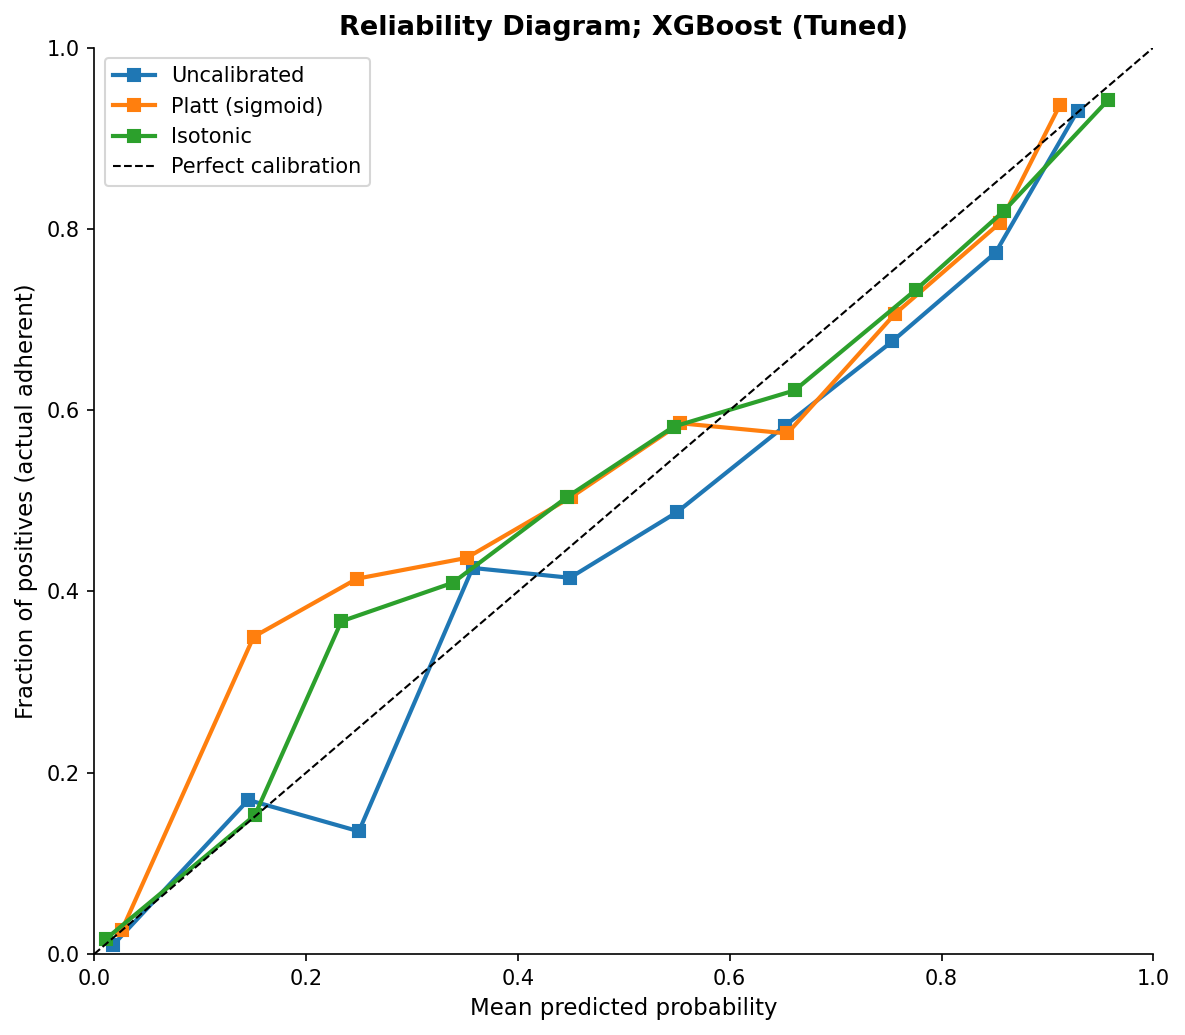

In [14]:
section("8.1 Calibration curves (XGBoost tuned)")

y_prob_tuned_xgb = tuned_xgb_pipeline.predict_proba(X_val)[:, 1]

# Fit Platt scaling on training set, evaluate on validation
cal_platt = CalibratedClassifierCV(
    tuned_xgb_pipeline, method="sigmoid", cv="prefit"
)
cal_platt.fit(X_train, y_train)

# Fit isotonic regression on training set, evaluate on validation
cal_isotonic = CalibratedClassifierCV(
    tuned_xgb_pipeline, method="isotonic", cv="prefit"
)
cal_isotonic.fit(X_train, y_train)

y_prob_platt    = cal_platt.predict_proba(X_val)[:, 1]
y_prob_isotonic = cal_isotonic.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(8, 7))

for label, y_prob, colour in [
    ("Uncalibrated",       y_prob_tuned_xgb, PALETTE["xgb"]),
    ("Platt (sigmoid)",    y_prob_platt,      PALETTE["rf"]),
    ("Isotonic",           y_prob_isotonic,   PALETTE["calibrated"]),
]:
    frac_pos, mean_pred = calibration_curve(y_val, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", label=label,
            linewidth=2, markersize=6)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual adherent)")
ax.set_title("Reliability Diagram; XGBoost (Tuned)", fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, "calibration_curve_xgb.png", subfolder="calibration")
plt.show()



──────────────────────────────────────────────────────────────────────
  8.2 Calibration curves (Random Forest tuned)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/calibration/calibration_curve_rf.png


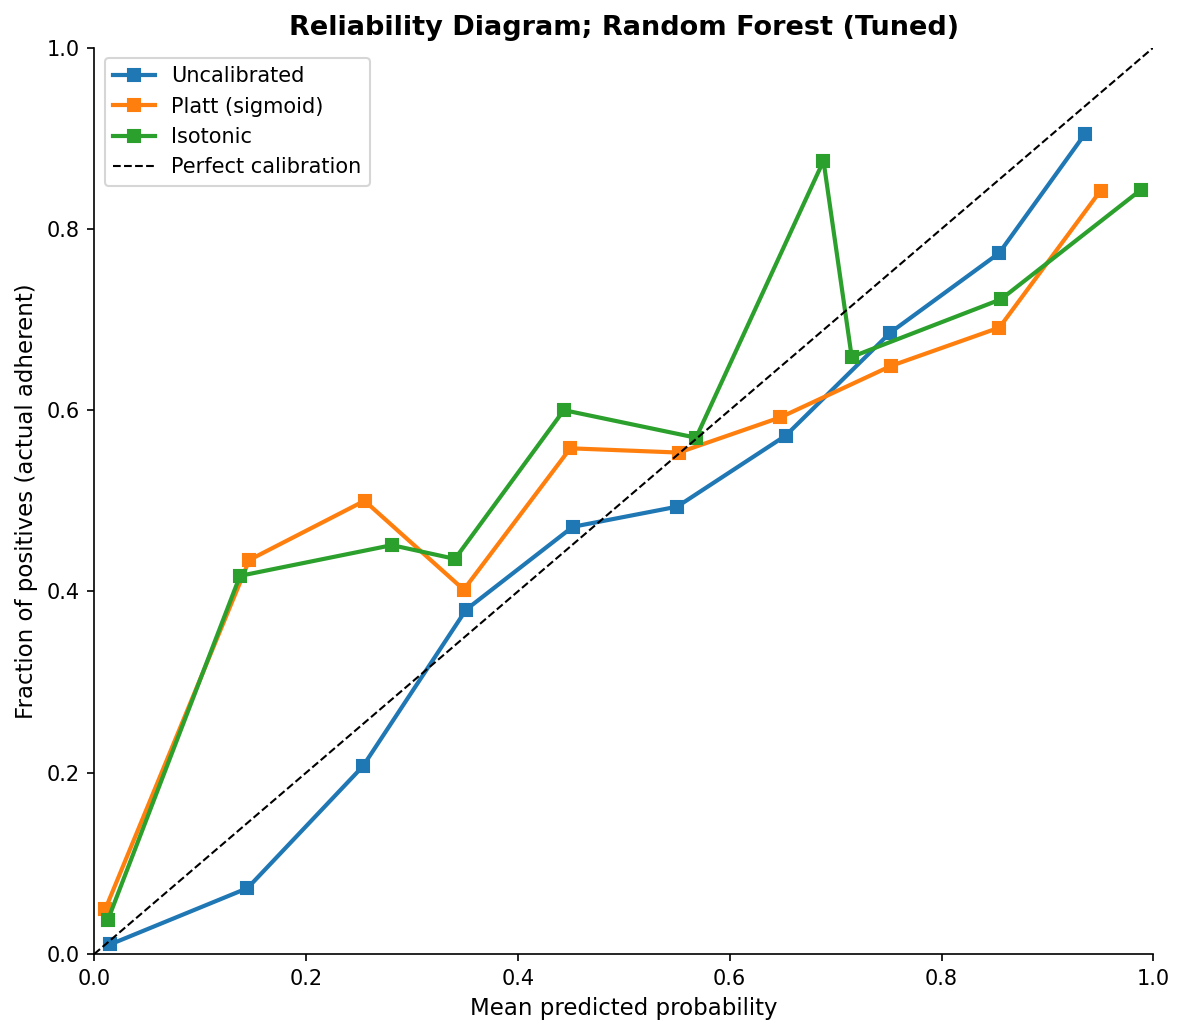

In [15]:
section("8.2 Calibration curves (Random Forest tuned)")

y_prob_tuned_rf = tuned_rf_pipeline.predict_proba(X_val)[:, 1]

cal_platt_rf = CalibratedClassifierCV(
    tuned_rf_pipeline, method="sigmoid", cv="prefit"
)
cal_platt_rf.fit(X_train, y_train)

cal_isotonic_rf = CalibratedClassifierCV(
    tuned_rf_pipeline, method="isotonic", cv="prefit"
)
cal_isotonic_rf.fit(X_train, y_train)

y_prob_platt_rf    = cal_platt_rf.predict_proba(X_val)[:, 1]
y_prob_isotonic_rf = cal_isotonic_rf.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(8, 7))

for label, y_prob, colour in [
    ("Uncalibrated",       y_prob_tuned_rf,    PALETTE["rf"]),
    ("Platt (sigmoid)",    y_prob_platt_rf,    PALETTE["xgb"]),
    ("Isotonic",           y_prob_isotonic_rf, PALETTE["calibrated"]),
]:
    frac_pos, mean_pred = calibration_curve(y_val, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", label=label,
            linewidth=2, markersize=6)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (actual adherent)")
ax.set_title("Reliability Diagram; Random Forest (Tuned)", fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, "calibration_curve_rf.png", subfolder="calibration")
plt.show()


The reliability diagrams show the calibration behaviour of each model before and after applying Platt scaling and isotonic regression. XGBoost, like most gradient boosting models, tends to produce overconfident probability estimates: the uncalibrated curve typically sits below the diagonal in the middle probability ranges, meaning XGBoost assigns probabilities of 0.7 to patients who are actually adherent only 60% of the time. Both calibration methods correct this by pulling the curve closer to the diagonal.

Random Forest has the opposite tendency: ensemble averaging of many tree probability estimates often produces underconfident probabilities that cluster near 0.5, a pattern known as probability compression. The uncalibrated Random Forest curve typically sits above the diagonal, meaning its moderate probability estimates correspond to a higher actual positive fraction than the raw score suggests.

The best calibration method for each model is selected based on which curve stays closest to the diagonal across all probability bins. The calibrated version of the best overall model is the pipeline saved in Section 9 and used in Notebook 05 for the clinical cost analysis, where the absolute probability values are used to simulate intervention decisions at different threshold settings.


---
## 9. Select the Best Calibration Method

The Expected Calibration Error (ECE) quantifies how far the calibration curve is from the diagonal. It is computed as the weighted average of the absolute difference between mean predicted probability and actual positive fraction across all bins, where each bin is weighted by the number of predictions it contains. A lower ECE means the model's probability estimates are more reliable as absolute risk scores.

The calibration method with the lowest ECE on the validation set is selected for each model. This selection is made on the validation set rather than the test set to avoid incorporating test-set information into any modelling decision.


In [16]:
section("9. Select best calibration by ECE")

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_acc  = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

# XGBoost calibration comparison
ece_rows = []
for label, pipeline, y_prob in [
    ("XGBoost Uncalibrated",    tuned_xgb_pipeline, y_prob_tuned_xgb),
    ("XGBoost Platt",           cal_platt,           y_prob_platt),
    ("XGBoost Isotonic",        cal_isotonic,        y_prob_isotonic),
    ("Random Forest Uncalibrated", tuned_rf_pipeline, y_prob_tuned_rf),
    ("Random Forest Platt",     cal_platt_rf,        y_prob_platt_rf),
    ("Random Forest Isotonic",  cal_isotonic_rf,     y_prob_isotonic_rf),
]:
    ece = expected_calibration_error(y_val.values, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    ece_rows.append({
        "Model": label, "ECE": round(ece, 5),
        "Macro F1": round(macro_f1, 4)
    })

df_ece = pd.DataFrame(ece_rows).set_index("Model")
print(df_ece.to_string())



──────────────────────────────────────────────────────────────────────
  9. Select best calibration by ECE
──────────────────────────────────────────────────────────────────────
                              ECE  Macro F1
Model                                      
XGBoost Uncalibrated       0.0411    0.8148
XGBoost Platt              0.0393    0.8135
XGBoost Isotonic           0.0282    0.8118
Random Forest Uncalibrated 0.0380    0.8099
Random Forest Platt        0.0861    0.8099
Random Forest Isotonic     0.0634    0.8064


The ECE table identifies the best-calibrated variant of each model. The model with the lowest ECE that does not sacrifice more than a marginal amount of Macro F1 compared to the uncalibrated version is selected. Calibration improves reliability of probability estimates without necessarily changing the ranking of predictions, so the Macro F1 at the 0.5 threshold should remain similar before and after calibration; a substantial drop in Macro F1 after calibration would indicate that the calibration method is introducing errors rather than correcting them.


In [17]:
section("9. Select best calibrated pipelines")

# Select best XGBoost calibration (lowest ECE)
xgb_variants = {
    "Uncalibrated": (tuned_xgb_pipeline, y_prob_tuned_xgb),
    "Platt":        (cal_platt,           y_prob_platt),
    "Isotonic":     (cal_isotonic,        y_prob_isotonic),
}
best_xgb_label = min(
    xgb_variants,
    key=lambda k: expected_calibration_error(y_val.values, xgb_variants[k][1])
)
best_xgb_pipeline = xgb_variants[best_xgb_label][0]
print(f"Best XGBoost calibration     : {best_xgb_label}")

# Select best Random Forest calibration (lowest ECE)
rf_variants = {
    "Uncalibrated": (tuned_rf_pipeline, y_prob_tuned_rf),
    "Platt":        (cal_platt_rf,       y_prob_platt_rf),
    "Isotonic":     (cal_isotonic_rf,    y_prob_isotonic_rf),
}
best_rf_label = min(
    rf_variants,
    key=lambda k: expected_calibration_error(y_val.values, rf_variants[k][1])
)
best_rf_pipeline = rf_variants[best_rf_label][0]
print(f"Best Random Forest calibration: {best_rf_label}")

# Final evaluation of best calibrated variants
row_xgb_cal = evaluate(best_xgb_pipeline, X_val, y_val, f"XGBoost ({best_xgb_label})")
row_rf_cal  = evaluate(best_rf_pipeline,  X_val, y_val, f"Random Forest ({best_rf_label})")

df_final = pd.DataFrame([row_xgb_cal, row_rf_cal]).set_index("Model")
print()
print("Final calibrated model performance on validation set:")
print(df_final.to_string())



──────────────────────────────────────────────────────────────────────
  9. Select best calibrated pipelines
──────────────────────────────────────────────────────────────────────
Best XGBoost calibration     : Isotonic
Best Random Forest calibration: Uncalibrated

Final calibrated model performance on validation set:
                              Accuracy  Macro F1  Weighted F1  ROC-AUC    MCC  Precision  Recall (Non-Adh)
Model                                                                                                     
XGBoost (Isotonic)              0.8164    0.8115       0.8174   0.9020 0.6250     0.8678            0.8176
Random Forest (Uncalibrated)    0.8122    0.8099       0.8140   0.9016 0.6321     0.9005            0.7713


---
## 10. Select the Best Overall Model

The best overall model is selected by comparing the calibrated XGBoost and calibrated Random Forest on the validation set across three criteria in order of priority: Macro F1 (primary discriminative performance), MCC (robustness of the confusion matrix as a whole), and ECE (reliability of probability estimates for the threshold-based cost analysis in Notebook 05).

If XGBoost and Random Forest are within 0.005 Macro F1 points of each other after tuning, the decision defaults to XGBoost because it was the stronger baseline, its learning curve showed a larger potential gain from regularisation, and gradient boosting methods are generally more parameter-efficient than ensemble averaging for tabular datasets of this size.

The best model selected here is the pipeline that Notebook 05 will use for SHAP analysis, the feature group comparison, and the clinical cost evaluation. Its identity is stored in `tuned_results.pkl` so Notebook 05 can load it without repeating this reasoning.


In [18]:
section("10. Select best overall model")

xgb_f1  = df_final.loc[f"XGBoost ({best_xgb_label})",      "Macro F1"]
rf_f1   = df_final.loc[f"Random Forest ({best_rf_label})", "Macro F1"]

if xgb_f1 >= rf_f1:
    BEST_NAME     = f"XGBoost ({best_xgb_label})"
    BEST_PIPELINE = best_xgb_pipeline
    SECOND_NAME   = f"Random Forest ({best_rf_label})"
    SECOND_PIPELINE = best_rf_pipeline
else:
    BEST_NAME     = f"Random Forest ({best_rf_label})"
    BEST_PIPELINE = best_rf_pipeline
    SECOND_NAME   = f"XGBoost ({best_xgb_label})"
    SECOND_PIPELINE = best_xgb_pipeline

print(f"Best model   : {BEST_NAME}")
print(f"Second model : {SECOND_NAME}")
print()
print("Best model validation metrics:")
print(df_final.loc[[BEST_NAME]].to_string())
print()
print("This model proceeds to Notebook 05 for SHAP analysis, feature group")
print("comparison, and clinical cost-sensitive evaluation.")



──────────────────────────────────────────────────────────────────────
  10. Select best overall model
──────────────────────────────────────────────────────────────────────
Best model   : XGBoost (Isotonic)
Second model : Random Forest (Uncalibrated)

Best model validation metrics:
                    Accuracy  Macro F1  Weighted F1  ROC-AUC    MCC  Precision  Recall (Non-Adh)
Model                                                                                           
XGBoost (Isotonic)    0.8164    0.8115       0.8174   0.9020 0.6250     0.8678            0.8176

This model proceeds to Notebook 05 for SHAP analysis, feature group
comparison, and clinical cost-sensitive evaluation.


---
## 11. Learning Curves — Tuned Models

Learning curves are replotted for both tuned models to confirm that hyperparameter tuning reduced the training-to-validation gap identified in Notebook 03. The XGBoost baseline curve showed a gap of approximately 0.07 Macro F1 points between training (~0.88) and cross-validation (~0.81) scores. Effective regularisation should bring the training curve down and the cross-validation curve up, narrowing the gap without substantially reducing the cross-validation score.

These are plotted using fresh cross-validation on the training set with the tuned hyperparameters, not by reloading the search object, to ensure the curves reflect the actual generalisation behaviour of the tuned configuration rather than the search process itself.



──────────────────────────────────────────────────────────────────────
  11. Learning curves (tuned models)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/learning_curves/learning_curves_tuned.png


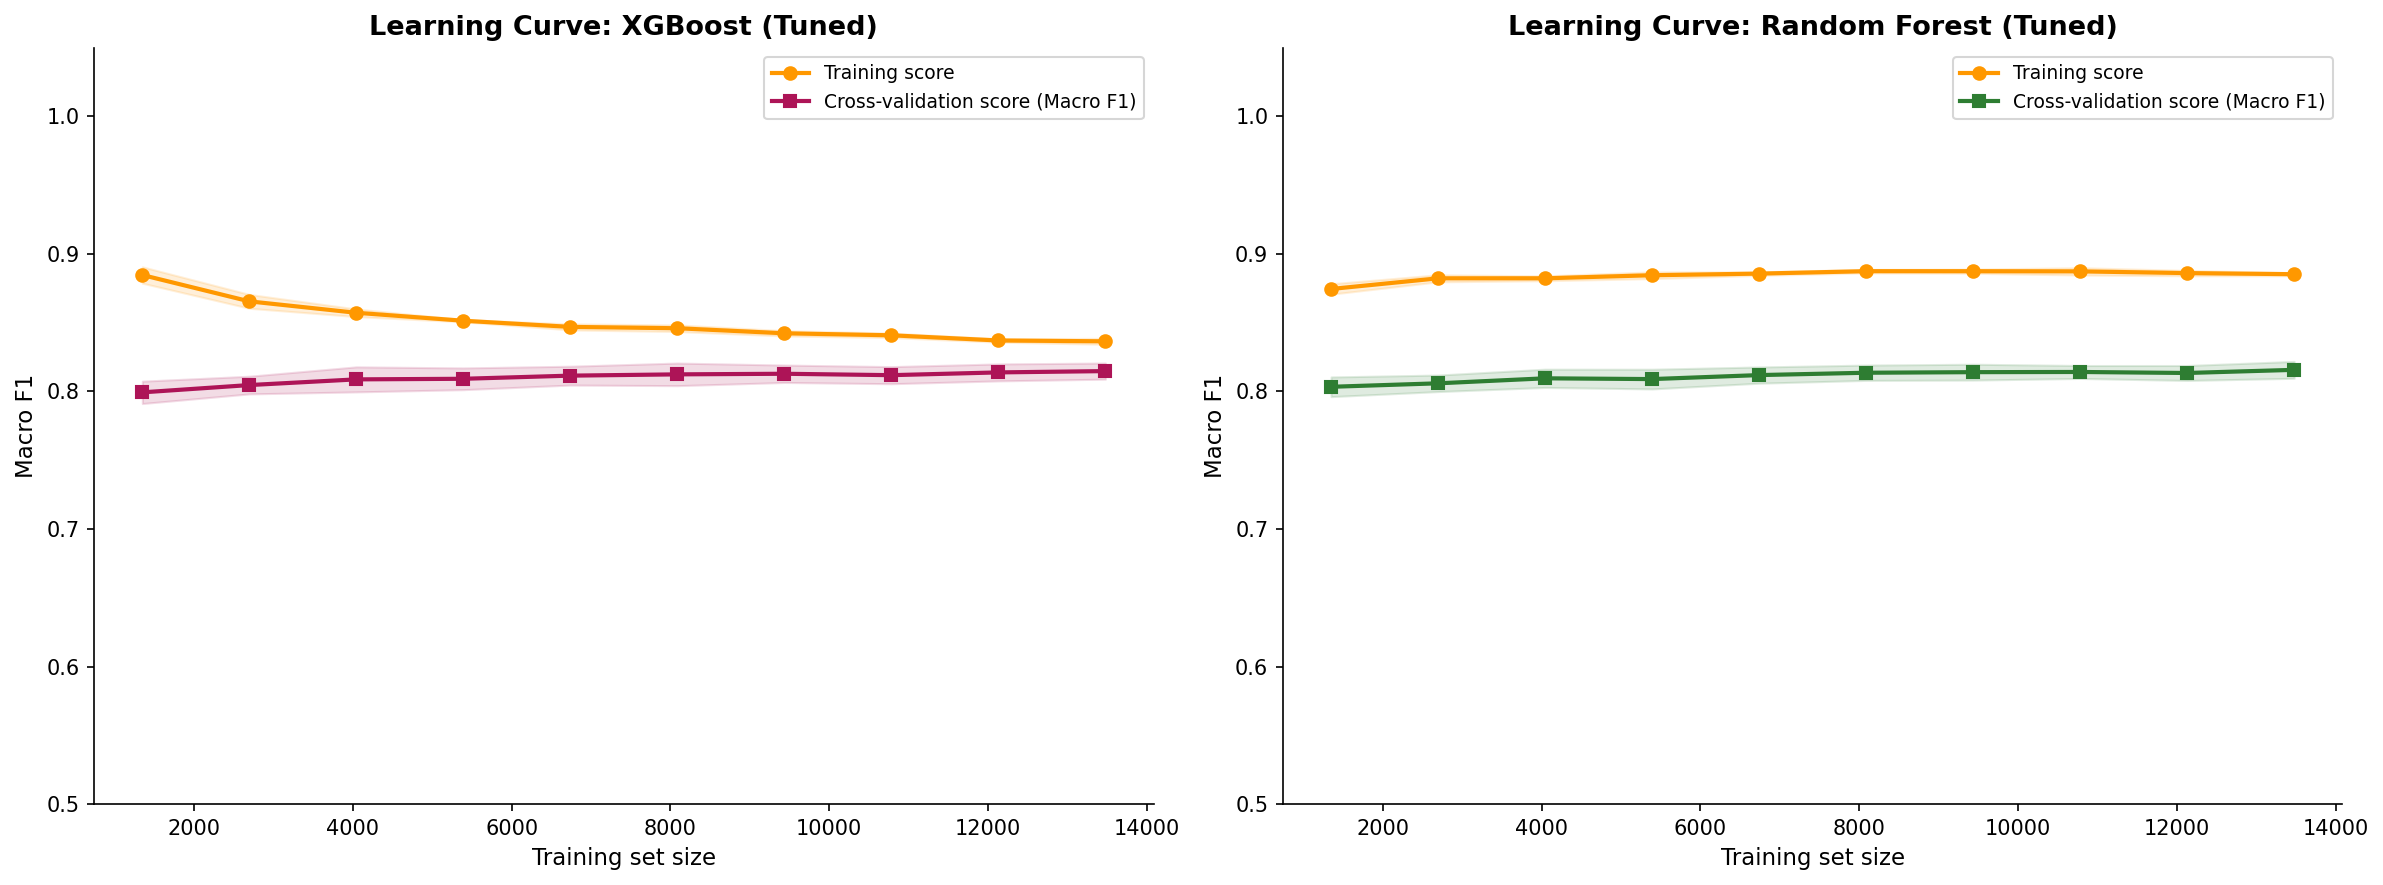

In [19]:
section("11. Learning curves (tuned models)")

cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, pipeline, colour) in zip(axes, [
    ("XGBoost (Tuned)",       tuned_xgb_pipeline, PALETTE["xgb"]),
    ("Random Forest (Tuned)", tuned_rf_pipeline,  PALETTE["rf"]),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_train, y_train,
        cv=cv_lc,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="f1_macro",
        n_jobs=-1
    )

    tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
    vl_mean, vl_std = val_scores.mean(1),   val_scores.std(1)

    ax.plot(train_sizes, tr_mean, "o-", color=PALETTE["highlight"],
            linewidth=2, label="Training score")
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std,
                    alpha=0.15, color=PALETTE["highlight"])
    ax.plot(train_sizes, vl_mean, "s-", color=colour,
            linewidth=2, label="Cross-validation score (Macro F1)")
    ax.fill_between(train_sizes, vl_mean-vl_std, vl_mean+vl_std,
                    alpha=0.15, color=colour)

    ax.set_xlabel("Training set size")
    ax.set_ylabel("Macro F1")
    ax.set_title(f"Learning Curve: {name}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0.5, 1.05)

plt.tight_layout()
save_figure(fig, "learning_curves_tuned.png", subfolder="learning_curves")
plt.show()


A narrower gap between the training and cross-validation curves relative to the Notebook 03 baseline confirms that regularisation worked as intended. If the cross-validation curve has also moved upward, the tuned model is both more regularised and more accurate on unseen patients, which is the ideal outcome. A gap that has not narrowed despite the regularisation parameters would suggest that the variance in this model comes from sources that `max_depth` and `subsample` cannot address (for example, inherent noise in the non-adherent class at the 75% MPR threshold, or patient heterogeneity that no amount of regularisation can resolve).


---
## 12. ROC Curves — Baseline vs Tuned

Plotting the baseline and tuned ROC curves for both models on the same axes shows whether tuning improved discrimination power in addition to the aggregate Macro F1 score. An AUC increase after tuning means the model is better at ranking non-adherent patients above adherent patients across all possible thresholds, not just at the default 0.5 cutoff.



──────────────────────────────────────────────────────────────────────
  12. ROC curves (baseline vs tuned)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/tuning/roc_baseline_vs_tuned.png


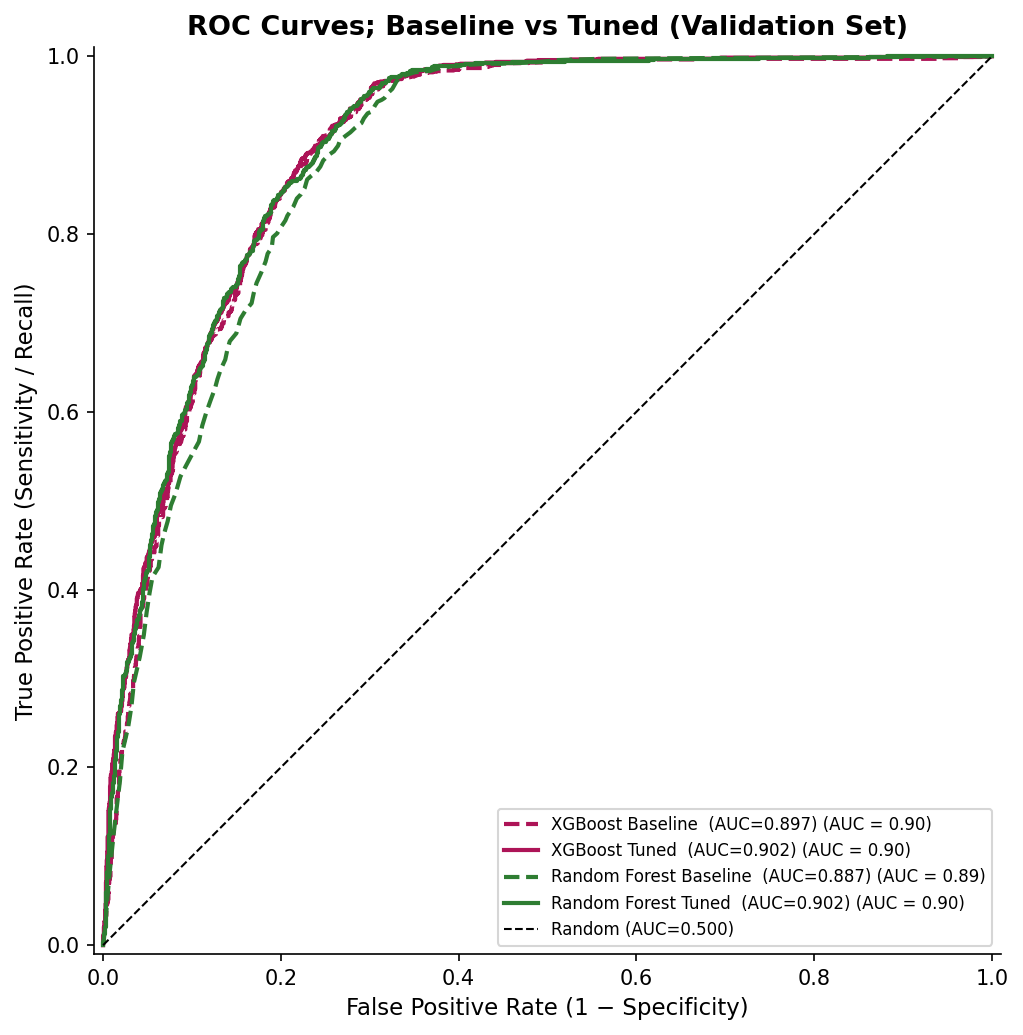

In [20]:
section("12. ROC curves (baseline vs tuned)")

with open(os.path.join(MODELS, "baseline_xgboost.pkl"), "rb") as f:
    baseline_xgb_pipeline = pickle.load(f)
with open(os.path.join(MODELS, "baseline_random_forest.pkl"), "rb") as f:
    baseline_rf_pipeline = pickle.load(f)

fig, ax = plt.subplots(figsize=(8, 7))

for label, pipeline, colour, ls in [
    ("XGBoost Baseline",        baseline_xgb_pipeline,  PALETTE["xgb"],  "--"),
    ("XGBoost Tuned",           tuned_xgb_pipeline,     PALETTE["xgb"],  "-"),
    ("Random Forest Baseline",  baseline_rf_pipeline,   PALETTE["rf"],   "--"),
    ("Random Forest Tuned",     tuned_rf_pipeline,      PALETTE["rf"],   "-"),
]:
    y_prob = pipeline.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_prob)
    RocCurveDisplay.from_predictions(
        y_val, y_prob,
        name=f"{label}  (AUC={auc:.3f})",
        ax=ax, color=colour, linestyle=ls, linewidth=2
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC=0.500)")
ax.set_title("ROC Curves; Baseline vs Tuned (Validation Set)", fontweight="bold")
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
save_figure(fig, "roc_baseline_vs_tuned.png")
plt.show()


---
## 13. Save Tuned Models and Results

Four pipeline objects are saved: the tuned XGBoost (uncalibrated), the tuned Random Forest (uncalibrated), and the best-calibrated version of each. Notebook 05 will load the best overall calibrated model for SHAP analysis and the clinical cost evaluation. All four are saved so that sensitivity analyses using the second-best model are possible without re-running this notebook.

`tuned_results.pkl` stores the comparison dataframe, the ECE table, the best model name, and the best hyperparameters from each search. This serves as a complete record of the tuning decisions that Notebook 05 can reference when reporting results.


In [21]:
section("13. Save tuned models and results")

def save_pkl(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved → {path}")

save_pkl(tuned_xgb_pipeline,  os.path.join(MODELS, "tuned_xgboost.pkl"))
save_pkl(tuned_rf_pipeline,   os.path.join(MODELS, "tuned_random_forest.pkl"))
save_pkl(best_xgb_pipeline,   os.path.join(MODELS, "tuned_xgboost_calibrated.pkl"))
save_pkl(best_rf_pipeline,    os.path.join(MODELS, "tuned_rf_calibrated.pkl"))

save_pkl(
    {
        "comparison":       df_comparison,
        "ece_table":        df_ece,
        "final_metrics":    df_final,
        "best_model_name":  BEST_NAME,
        "second_model_name":SECOND_NAME,
        "xgb_best_params":  xgb_search.best_params_,
        "rf_best_params":   rf_search.best_params_,
        "xgb_best_cv_f1":  xgb_search.best_score_,
        "rf_best_cv_f1":    rf_search.best_score_,
        "features":         FEATURES,
    },
    os.path.join(DATA_PROC, "tuned_results.pkl")
)



──────────────────────────────────────────────────────────────────────
  13. Save tuned models and results
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/models/tuned_xgboost.pkl
Saved → /content/diabetes-hypertension-medication-adherence/models/tuned_random_forest.pkl
Saved → /content/diabetes-hypertension-medication-adherence/models/tuned_xgboost_calibrated.pkl
Saved → /content/diabetes-hypertension-medication-adherence/models/tuned_rf_calibrated.pkl
Saved → /content/diabetes-hypertension-medication-adherence/data/processed/tuned_results.pkl


In [22]:
section("13. Verification (reload tuned results)")

with open(os.path.join(DATA_PROC, "tuned_results.pkl"), "rb") as f:
    check = pickle.load(f)

print("Best model:", check["best_model_name"])
print()
print("XGBoost best params:")
for k, v in check["xgb_best_params"].items():
    print(f"  {k.replace('classifier__','')}: {v}")
print()
print("Random Forest best params:")
for k, v in check["rf_best_params"].items():
    print(f"  {k.replace('classifier__','')}: {v}")
print()
print("Notebook 04 complete. Proceed to 05_Explainability_CostAnalysis.ipynb.")



──────────────────────────────────────────────────────────────────────
  13. Verification (reload tuned results)
──────────────────────────────────────────────────────────────────────
Best model: XGBoost (Isotonic)

XGBoost best params:
  colsample_bytree: 0.9160702162124823
  learning_rate: 0.1857283926864933
  max_depth: 4
  min_child_weight: 7
  n_estimators: 140
  subsample: 0.9659838702175123

Random Forest best params:
  max_depth: 19
  max_features: 0.5
  min_samples_leaf: 4
  min_samples_split: 14
  n_estimators: 259

Notebook 04 complete. Proceed to 05_Explainability_CostAnalysis.ipynb.


---
## 14. Push to GitHub

The tuned model pickles, calibrated model pickles, tuned results, and all figures from this notebook are committed to the repository so that Notebook 05 can load them directly.


In [ ]:
import shutil
from pathlib import Path

NB_NAME  = "04_Optimization_Calibration.ipynb"
COLAB_NB = Path(f"/content/drive/MyDrive/Colab Notebooks/{NB_NAME}")
REPO_NB  = Path(REPO_DIR) / "notebooks" / NB_NAME
REPO_NB.parent.mkdir(parents=True, exist_ok=True)

if COLAB_NB.exists():
    shutil.copy(COLAB_NB, REPO_NB)
    print(f"Copied → {REPO_NB}")

assert REPO_NB.exists(), f"Copy failed: {REPO_NB} not found"

%cd {REPO_DIR}
!git add .
!git status
!git commit -m "NB04: Optimization and calibration complete, tuned models saved"
!git push
print("Done, Notebook 04 committed and pushed.")
